### 🧪 Feature Engineering Strategy for Churn Prediction

To enhance model performance and interpretability, the following engineered features are proposed based on SHAP insights and domain intuition:

### 🔁 Tenure-Based Features
- **TenureBucket**: Categorize tenure into bins (e.g., 0–6, 6–12, 12–24, 24+ months).
- **TenureToContractRatio**: Tenure divided by contract length (if available)—captures loyalty vs. commitment.

### 💳 Billing & Payment Behavior
- **AvgMonthlyChargePerService**: MonthlyCharges divided by number of active services.
- **IsAutoPay**: Binary flag for automatic payments—may correlate with lower churn.
- **ChargeVolatility**: Standard deviation of monthly charges over time (if time-series data available).

### 🧩 Service Engagement
- **TotalServices**: Count of subscribed services (e.g., Internet, Phone, Streaming).
- **MissingServices**: Count of services not subscribed—could indicate low engagement.
- **SupportGap**: Binary flag if customer lacks both TechSupport and OnlineSecurity.

### 🧠 Interaction Features
- **Contract × Tenure**: Captures how contract type moderates tenure impact.
- **MonthlyCharges × TechSupport**: High charges without support may signal dissatisfaction.

### 📊 Derived KPIs
- **TenureToAgeRatio**: Loyalty relative to customer age (if age is available).
- **HighChargeFlag**: Flag customers above a certain monthly charge threshold.
- **EngagementScore**: Weighted sum of active services, based on SHAP importance.

These features aim to improve recall for churners, enhance model interpretability, and align predictions with actionable business insights.


In [1]:
import pandas as pd
import numpy as np
#EDA
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('churn_data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Data Wrangling

### Cleaning TotalCharges

In [6]:
# Strip whitespace and replace blanks with NaN
df['TotalCharges'] = df['TotalCharges'].replace(" ", pd.NA)

In [7]:
# Convert to numeric type
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
# Check nulls
df['TotalCharges'].isnull().sum()

11

In [9]:
# Replace the NaNs with average column value
avg_val = df['TotalCharges'].astype('float').mean(axis=0)

df['TotalCharges'].replace(np.nan, avg_val, inplace=True)

In [10]:
df['TotalCharges'].isnull().sum()

0

# Feature Engineering

### Drop CustomerID

In [11]:
df= df.drop(columns=['customerID'])

In [12]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Convert indicator variables to binary

In [13]:

col_names = ['Partner','Dependents','OnlineSecurity','OnlineBackup',
             'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling', 'Churn']

for col in col_names:
    df[col]=df[col].map({'Yes':1,'No':0})
    print('Updated column',col,'!')


Updated column Partner !
Updated column Dependents !
Updated column OnlineSecurity !
Updated column OnlineBackup !
Updated column DeviceProtection !
Updated column TechSupport !
Updated column StreamingTV !
Updated column StreamingMovies !
Updated column PaperlessBilling !
Updated column Churn !


In [14]:
# Changing the category 'No Phone Service' to 'No' in PhoneService
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

In [15]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,No,No,DSL,0.0,1.0,0.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,Yes,No,DSL,1.0,0.0,1.0,0.0,0.0,0.0,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,Yes,No,DSL,1.0,1.0,0.0,0.0,0.0,0.0,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,No,No,DSL,1.0,0.0,1.0,1.0,0.0,0.0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,Yes,No,Fiber optic,0.0,0.0,0.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,70.70,151.65,1


### Categorizing tenure

In [16]:
def categorize_tenure(months):
    if months <= 6:
        return 'New'
    elif months <= 24:
        return 'Short-term'
    elif months <= 48:
        return 'Mid-term'
    else:
        return 'Long-term'

df['TenureCategory'] = df['tenure'].apply(categorize_tenure)

In [17]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['TenureCode'] = le.fit_transform(df['TenureCategory'])

In [18]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureCategory,TenureCode
0,Female,0,1,0,1,No,No,DSL,0.0,1.0,...,0.0,0.0,Month-to-month,1,Electronic check,29.85,29.85,0,New,2
1,Male,0,0,0,34,Yes,No,DSL,1.0,0.0,...,0.0,0.0,One year,0,Mailed check,56.95,1889.50,0,Mid-term,1
2,Male,0,0,0,2,Yes,No,DSL,1.0,1.0,...,0.0,0.0,Month-to-month,1,Mailed check,53.85,108.15,1,New,2
3,Male,0,0,0,45,No,No,DSL,1.0,0.0,...,0.0,0.0,One year,0,Bank transfer (automatic),42.30,1840.75,0,Mid-term,1
4,Female,0,0,0,2,Yes,No,Fiber optic,0.0,0.0,...,0.0,0.0,Month-to-month,1,Electronic check,70.70,151.65,1,New,2


### Encoding Contract

In [19]:
# Encode the contract for model training
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['ContractCode'] = le.fit_transform(df['Contract']) 

In [20]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureCategory,TenureCode,ContractCode
0,Female,0,1,0,1,No,No,DSL,0.0,1.0,...,0.0,Month-to-month,1,Electronic check,29.85,29.85,0,New,2,0
1,Male,0,0,0,34,Yes,No,DSL,1.0,0.0,...,0.0,One year,0,Mailed check,56.95,1889.50,0,Mid-term,1,1
2,Male,0,0,0,2,Yes,No,DSL,1.0,1.0,...,0.0,Month-to-month,1,Mailed check,53.85,108.15,1,New,2,0
3,Male,0,0,0,45,No,No,DSL,1.0,0.0,...,0.0,One year,0,Bank transfer (automatic),42.30,1840.75,0,Mid-term,1,1
4,Female,0,0,0,2,Yes,No,Fiber optic,0.0,0.0,...,0.0,Month-to-month,1,Electronic check,70.70,151.65,1,New,2,0


In [21]:
df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

### Autopayments


In [22]:
def categorize_payment(payment):
    if payment == 'Electronic check':
        return 'No'
    if payment == 'Mailed check':
        return 'No'
    if payment == 'Bank transfer (automatic)':
        return 'Yes'
    if payment == 'Credit card (automatic)':
        return 'Yes'

df['Autopayment'] = df['PaymentMethod'].apply(categorize_payment)

In [23]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureCategory,TenureCode,ContractCode,Autopayment
0,Female,0,1,0,1,No,No,DSL,0.0,1.0,...,Month-to-month,1,Electronic check,29.85,29.85,0,New,2,0,No
1,Male,0,0,0,34,Yes,No,DSL,1.0,0.0,...,One year,0,Mailed check,56.95,1889.50,0,Mid-term,1,1,No
2,Male,0,0,0,2,Yes,No,DSL,1.0,1.0,...,Month-to-month,1,Mailed check,53.85,108.15,1,New,2,0,No
3,Male,0,0,0,45,No,No,DSL,1.0,0.0,...,One year,0,Bank transfer (automatic),42.30,1840.75,0,Mid-term,1,1,Yes
4,Female,0,0,0,2,Yes,No,Fiber optic,0.0,0.0,...,Month-to-month,1,Electronic check,70.70,151.65,1,New,2,0,No


## Encoding MultipleLines

In [24]:
df['MultipleLines']= le.fit_transform(df['MultipleLines'])

In [25]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureCategory,TenureCode,ContractCode,Autopayment
0,Female,0,1,0,1,No,0,DSL,0.0,1.0,...,Month-to-month,1,Electronic check,29.85,29.85,0,New,2,0,No
1,Male,0,0,0,34,Yes,0,DSL,1.0,0.0,...,One year,0,Mailed check,56.95,1889.50,0,Mid-term,1,1,No
2,Male,0,0,0,2,Yes,0,DSL,1.0,1.0,...,Month-to-month,1,Mailed check,53.85,108.15,1,New,2,0,No
3,Male,0,0,0,45,No,0,DSL,1.0,0.0,...,One year,0,Bank transfer (automatic),42.30,1840.75,0,Mid-term,1,1,Yes
4,Female,0,0,0,2,Yes,0,Fiber optic,0.0,0.0,...,Month-to-month,1,Electronic check,70.70,151.65,1,New,2,0,No


### Internet service

In [26]:
df['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [27]:
def internet(service):
    if service=='DSL':
        return 'Yes'
    elif service =='Fiber optic':
        return 'Yes'
    else:
        return 'No'

df['has_internet'] = df['InternetService'].apply(internet)

In [28]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureCategory,TenureCode,ContractCode,Autopayment,has_internet
0,Female,0,1,0,1,No,0,DSL,0.0,1.0,...,1,Electronic check,29.85,29.85,0,New,2,0,No,Yes
1,Male,0,0,0,34,Yes,0,DSL,1.0,0.0,...,0,Mailed check,56.95,1889.50,0,Mid-term,1,1,No,Yes
2,Male,0,0,0,2,Yes,0,DSL,1.0,1.0,...,1,Mailed check,53.85,108.15,1,New,2,0,No,Yes
3,Male,0,0,0,45,No,0,DSL,1.0,0.0,...,0,Bank transfer (automatic),42.30,1840.75,0,Mid-term,1,1,Yes,Yes
4,Female,0,0,0,2,Yes,0,Fiber optic,0.0,0.0,...,1,Electronic check,70.70,151.65,1,New,2,0,No,Yes


### Binary encoding gender

In [29]:
df['gender'] = (df['gender'] == 'Male').astype(int)

In [30]:
# 0-female
# 1-Male

In [31]:
# encoding Autopayment
df['Autopayment'] = (df['Autopayment'] == 'Yes').astype(int)

In [32]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureCategory,TenureCode,ContractCode,Autopayment,has_internet
0,0,0,1,0,1,No,0,DSL,0.0,1.0,...,1,Electronic check,29.85,29.85,0,New,2,0,0,Yes
1,1,0,0,0,34,Yes,0,DSL,1.0,0.0,...,0,Mailed check,56.95,1889.50,0,Mid-term,1,1,0,Yes
2,1,0,0,0,2,Yes,0,DSL,1.0,1.0,...,1,Mailed check,53.85,108.15,1,New,2,0,0,Yes
3,1,0,0,0,45,No,0,DSL,1.0,0.0,...,0,Bank transfer (automatic),42.30,1840.75,0,Mid-term,1,1,1,Yes
4,0,0,0,0,2,Yes,0,Fiber optic,0.0,0.0,...,1,Electronic check,70.70,151.65,1,New,2,0,0,Yes


In [33]:
#df.to_csv('churn_data2.csv',index=False)

### Number of services

In [34]:
# Define service columns
service_cols = [
    'PhoneService', 'MultipleLines', 'has_internet',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Map service values to binary: 1 if service is active, 0 otherwise
df_services = df[service_cols].replace({
    'Yes': 1,
    'No': 0,
    'No internet service': 0,
    'No phone service': 0
})

# Count number of active services per customer
df['NumServices'] = df_services.sum(axis=1)

In [35]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureCategory,TenureCode,ContractCode,Autopayment,has_internet,NumServices
0,0,0,1,0,1,No,0,DSL,0.0,1.0,...,Electronic check,29.85,29.85,0,New,2,0,0,Yes,2.0
1,1,0,0,0,34,Yes,0,DSL,1.0,0.0,...,Mailed check,56.95,1889.50,0,Mid-term,1,1,0,Yes,4.0
2,1,0,0,0,2,Yes,0,DSL,1.0,1.0,...,Mailed check,53.85,108.15,1,New,2,0,0,Yes,4.0
3,1,0,0,0,45,No,0,DSL,1.0,0.0,...,Bank transfer (automatic),42.30,1840.75,0,Mid-term,1,1,1,Yes,4.0
4,0,0,0,0,2,Yes,0,Fiber optic,0.0,0.0,...,Electronic check,70.70,151.65,1,New,2,0,0,Yes,2.0


In [36]:
df['NumServices'].unique()

array([2., 4., 6., 5., 7., 3., 1., 9., 8.])

In [37]:
df.isnull().sum()

gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
TenureCategory         0
TenureCode             0
ContractCode           0
Autopayment            0
has_internet           0
NumServices            0
dtype: int64

In [38]:
# convert ha_internet to binary
df['has_internet']=df['has_internet'].map({'Yes':1,'No':0})

In [39]:
#check if the nulls occour when the customer has no interner service. 
df.loc[df['OnlineSecurity'].isnull(), 'has_internet'].value_counts()

has_internet
0    1526
Name: count, dtype: int64

**Nulls in service features corresponded to customers without internet. Since features were binary‑encoded, imputing with 0 preserved domain meaning (no service) while simplifying the feature space.**

In [40]:
# replace the nulls with 0
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
df[service_cols] = df[service_cols].fillna(0)

In [41]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
TenureCategory      0
TenureCode          0
ContractCode        0
Autopayment         0
has_internet        0
NumServices         0
dtype: int64

# EDA

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int32  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   int32  
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   float64
 9   OnlineBackup      7043 non-null   float64
 10  DeviceProtection  7043 non-null   float64
 11  TechSupport       7043 non-null   float64
 12  StreamingTV       7043 non-null   float64
 13  StreamingMovies   7043 non-null   float64
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


In [43]:
df.describe(include='all')

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureCategory,TenureCode,ContractCode,Autopayment,has_internet,NumServices
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043,7043.000000,7043,7043.000000,7043.000000,...,7043,7043.000000,7043.000000,7043.000000,7043,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
unique,NaN,NaN,NaN,NaN,NaN,2,NaN,3,NaN,NaN,...,4,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,Yes,NaN,Fiber optic,NaN,NaN,...,Electronic check,NaN,NaN,NaN,Long-term,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,6361,NaN,3096,NaN,NaN,...,2365,NaN,NaN,NaN,2239,NaN,NaN,NaN,NaN,NaN
mean,0.504756,0.162147,0.483033,0.299588,32.371149,NaN,0.421837,NaN,0.286668,0.344881,...,NaN,64.761692,2283.300441,0.265370,NaN,1.383359,0.690473,0.435326,0.783331,4.146244
std,0.500013,0.368612,0.499748,0.458110,24.559481,NaN,0.493888,NaN,0.452237,0.475363,...,NaN,30.090047,2265.000258,0.441561,NaN,1.167639,0.833755,0.495835,0.412004,2.312720
min,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,0.000000,0.000000,...,NaN,18.250000,18.800000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,NaN,0.000000,NaN,0.000000,0.000000,...,NaN,35.500000,402.225000,0.000000,NaN,0.000000,0.000000,0.000000,1.000000,2.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,NaN,0.000000,NaN,0.000000,0.000000,...,NaN,70.350000,1400.550000,0.000000,NaN,1.000000,0.000000,0.000000,1.000000,4.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,NaN,1.000000,NaN,1.000000,1.000000,...,NaN,89.850000,3786.600000,1.000000,NaN,2.000000,1.000000,1.000000,1.000000,6.000000


In [44]:
# Missing values summary
df.isnull().sum().sort_values(ascending=False)

gender              0
SeniorCitizen       0
has_internet        0
Autopayment         0
ContractCode        0
TenureCode          0
TenureCategory      0
Churn               0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
DeviceProtection    0
OnlineBackup        0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
NumServices         0
dtype: int64

## EDA (Visual Analysis)

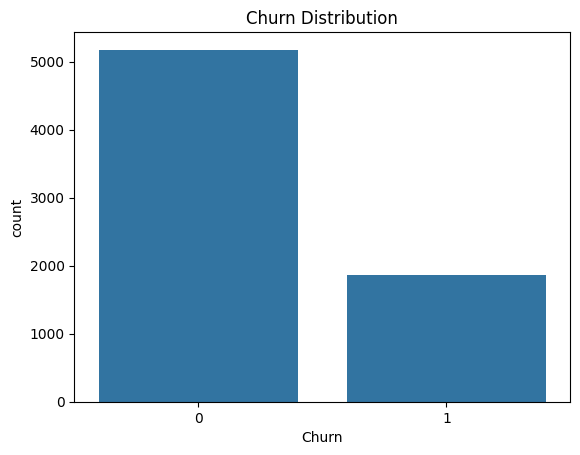

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [45]:
# Target Variable distribution

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()
print(df['Churn'].value_counts(normalize=True))

### Interpretation
- The dataset shows that approximately **26.5% of customers churned**, indicating a moderate class imbalance.
- This imbalance suggests that evaluation metrics beyond accuracy (e.g., precision, recall, F1) will be important.

### Univariate Analysis

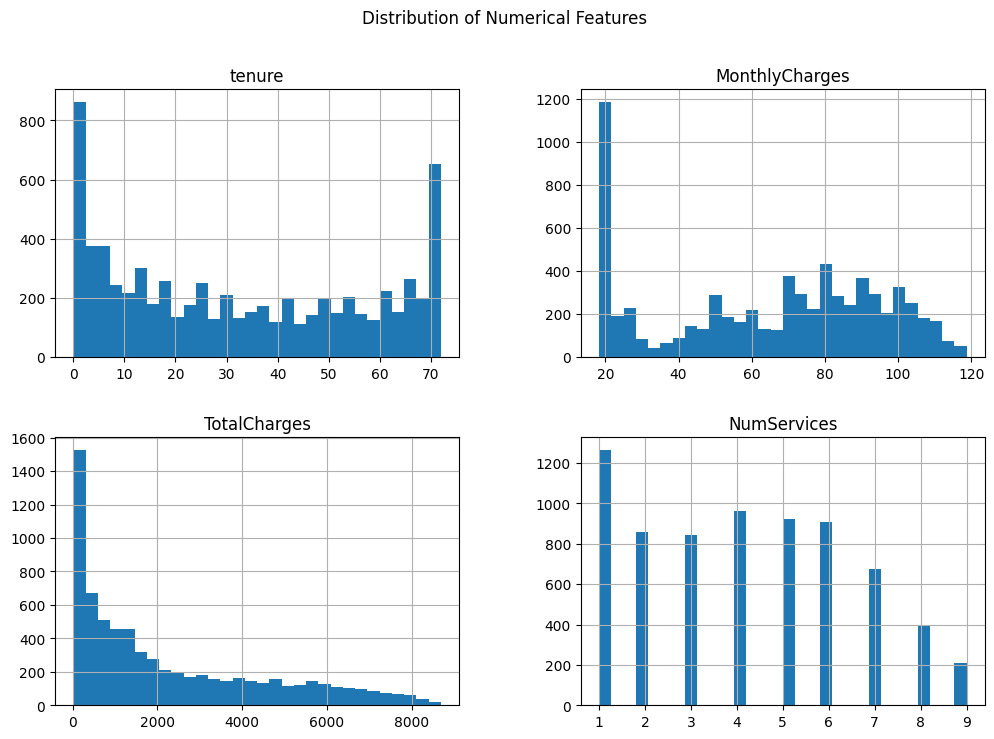

In [46]:
# Numerical Features
num_cols = ['tenure','MonthlyCharges','TotalCharges','NumServices']

df[num_cols].hist(bins=30, figsize=(12,8))
plt.suptitle("Distribution of Numerical Features")
plt.show()

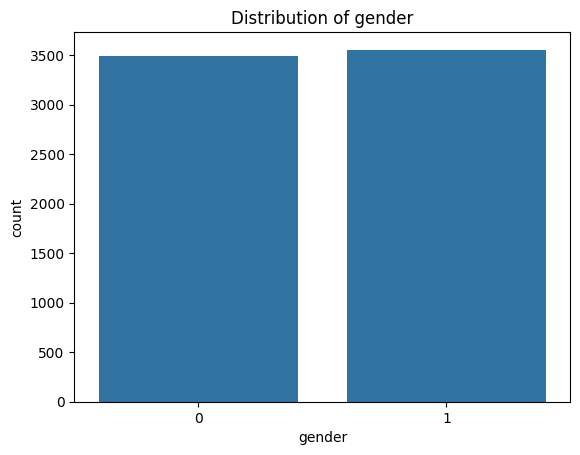

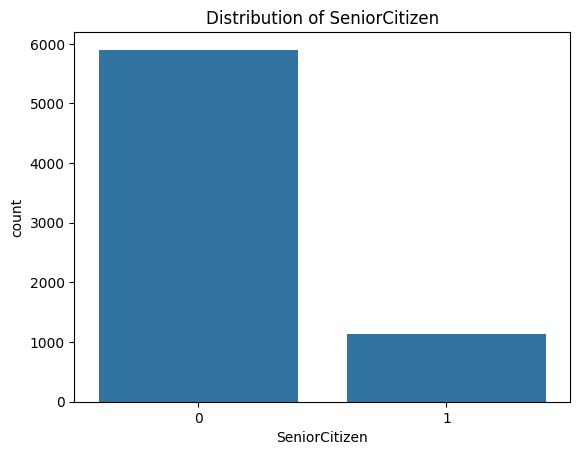

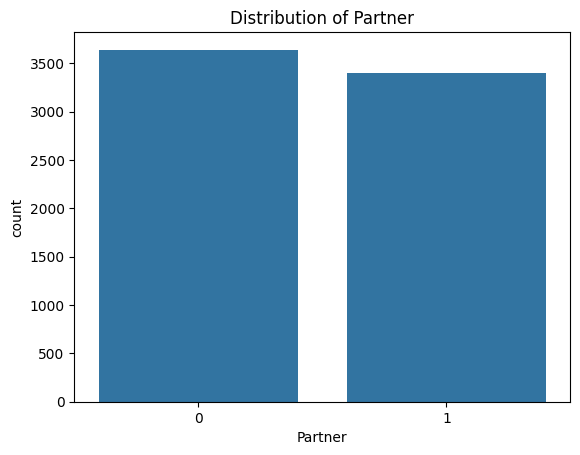

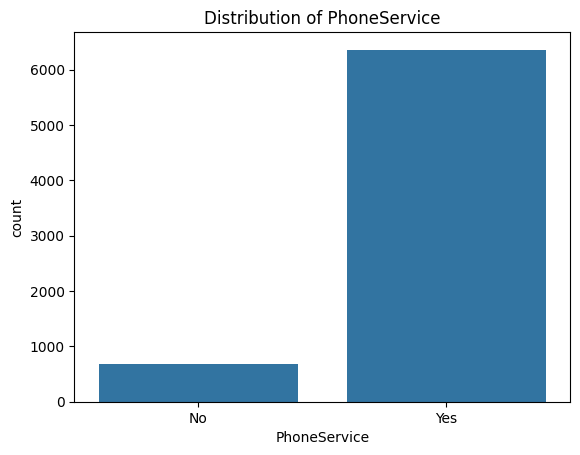

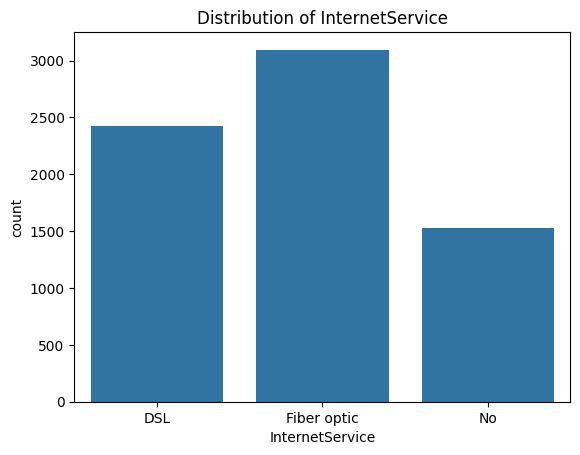

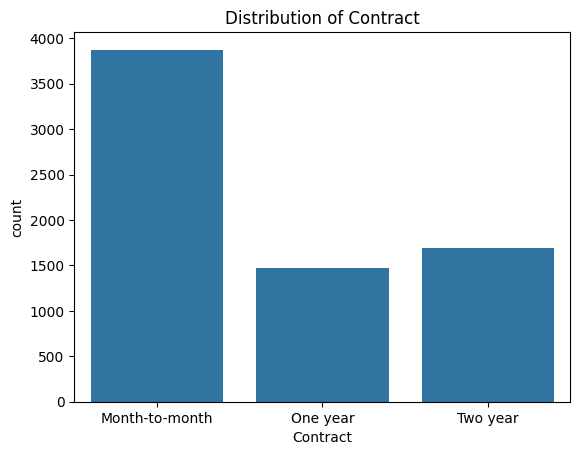

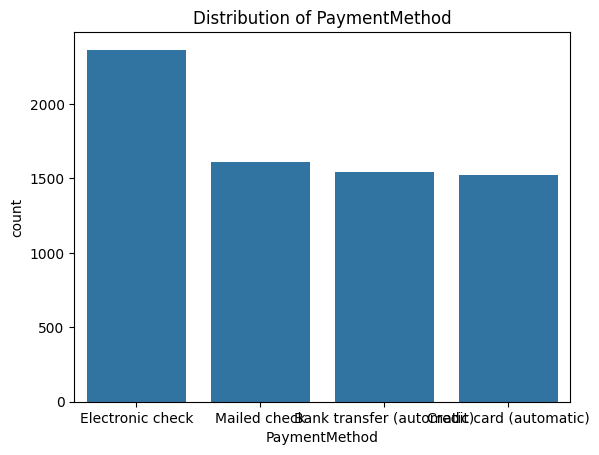

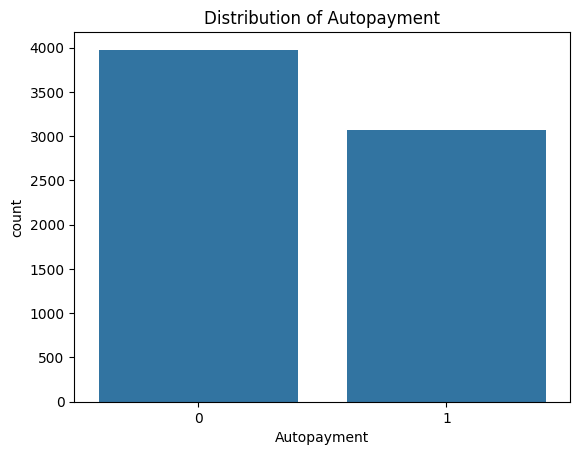

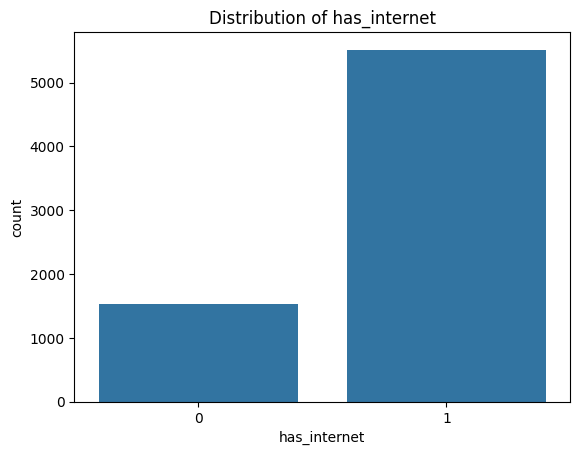

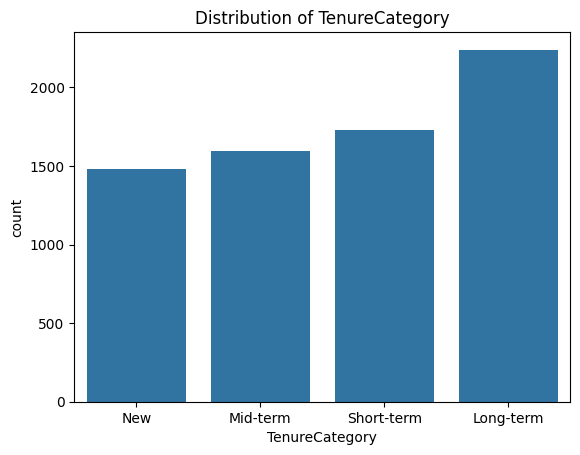

In [47]:
# Categorical Features
cat_cols = ['gender','SeniorCitizen','Partner',
            'PhoneService','InternetService','Contract',
            'PaymentMethod','Autopayment', 'has_internet','TenureCategory']

for col in cat_cols:
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()


### Bivariate Analysis with Churn

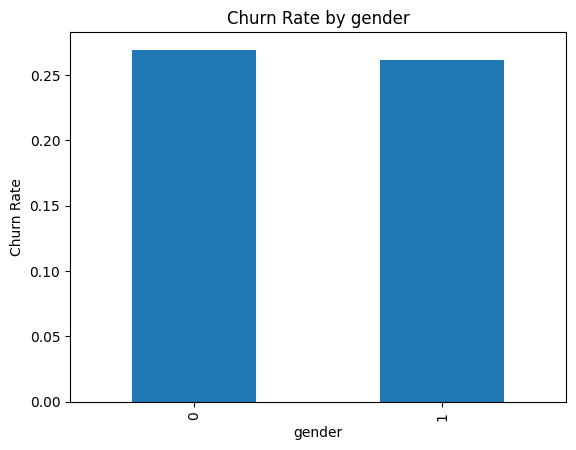

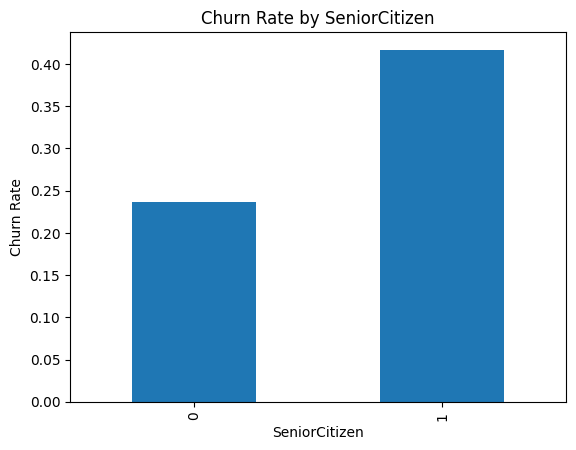

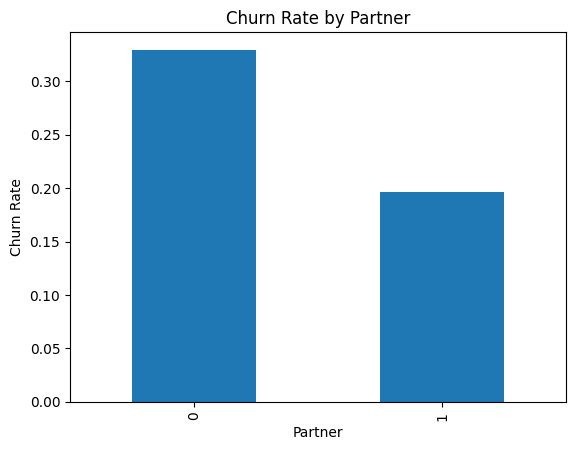

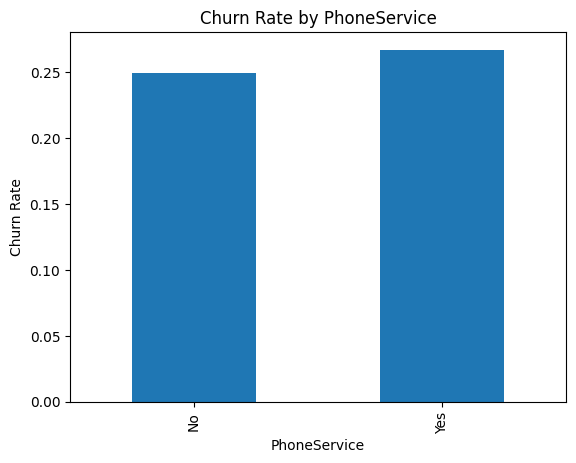

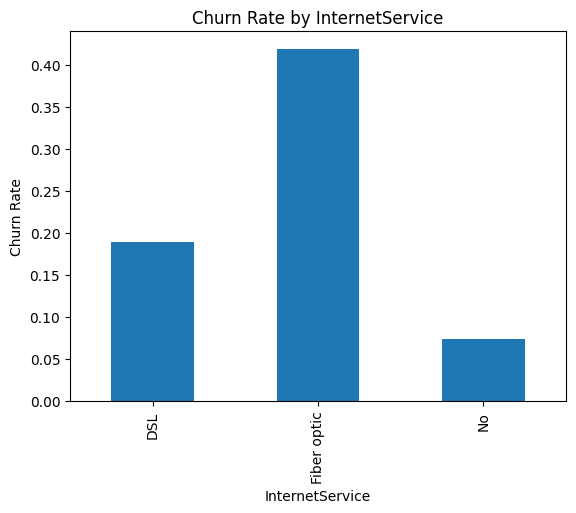

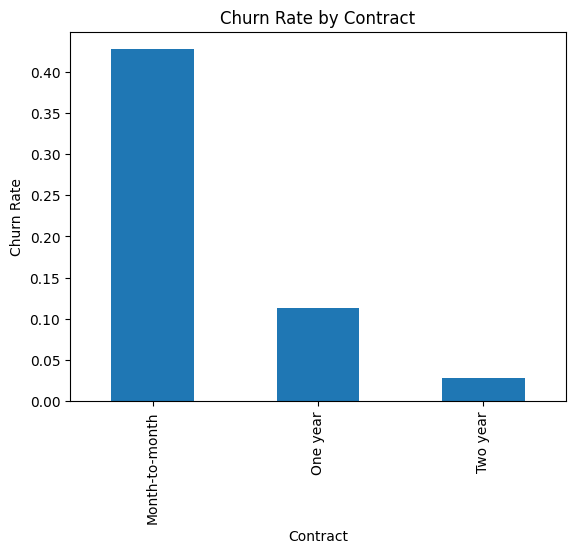

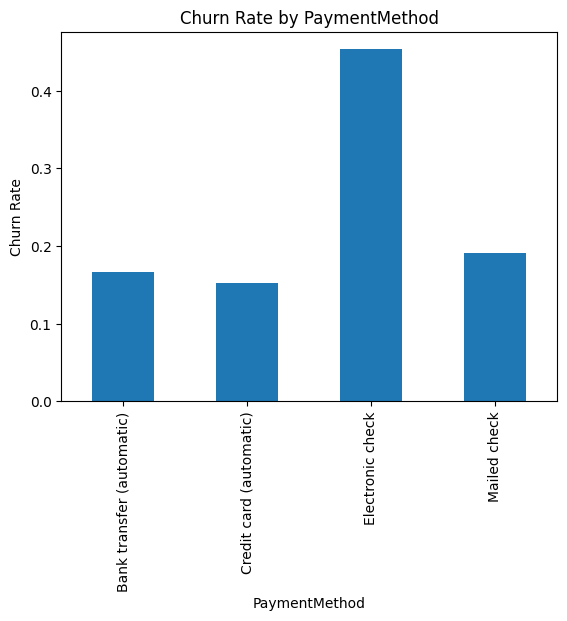

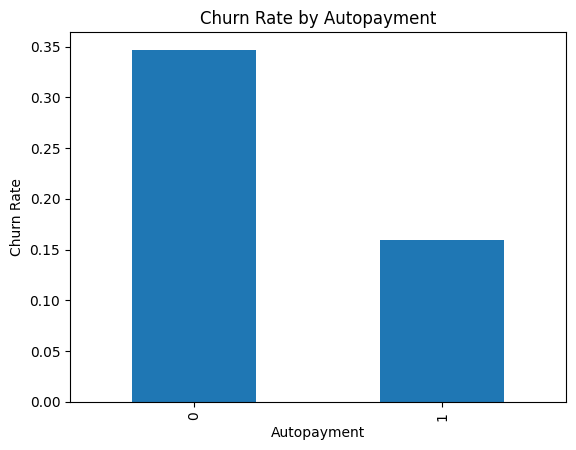

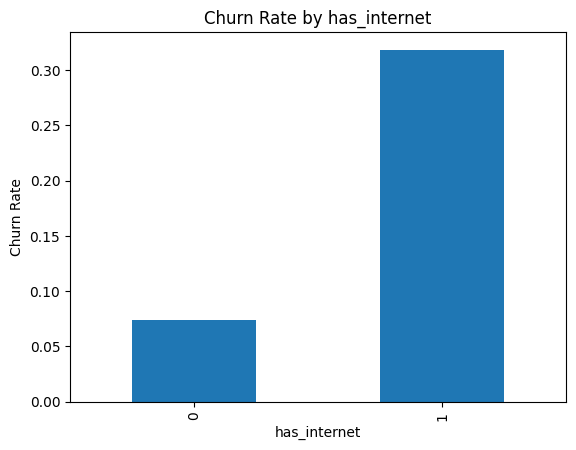

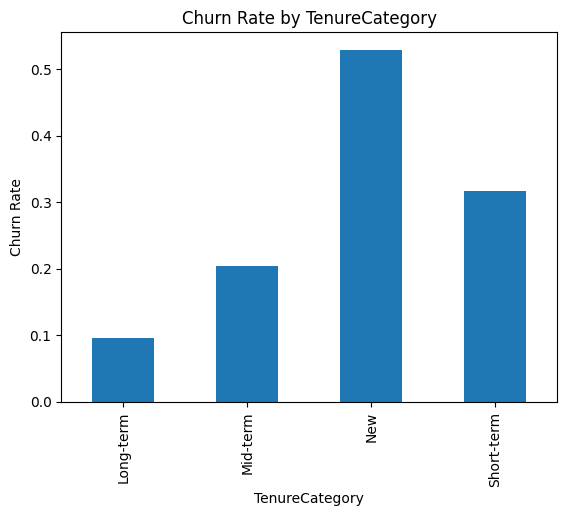

In [48]:
# Categoricals vs Churn
for col in cat_cols:
    churn_rate = df.groupby(col)['Churn'].mean()
    churn_rate.plot(kind='bar', title=f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.show()

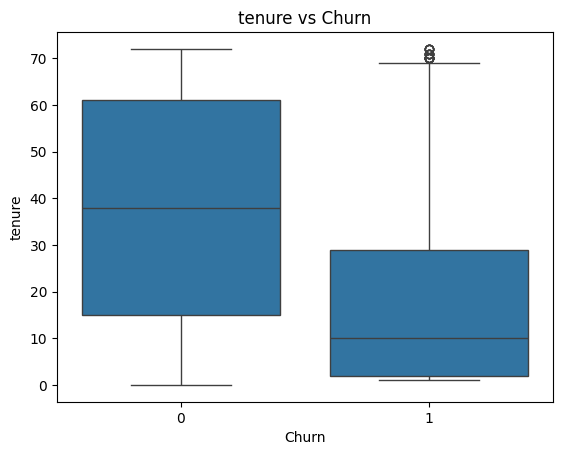

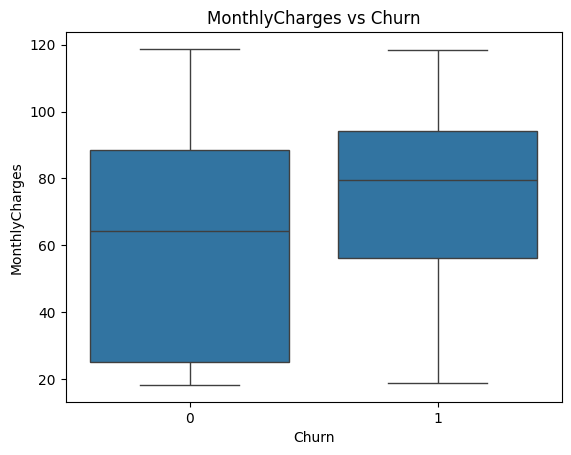

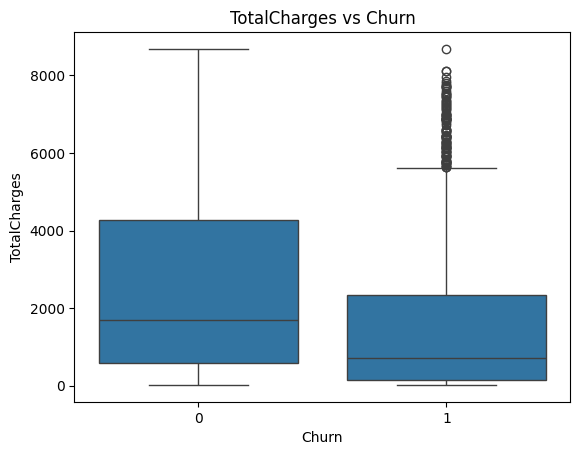

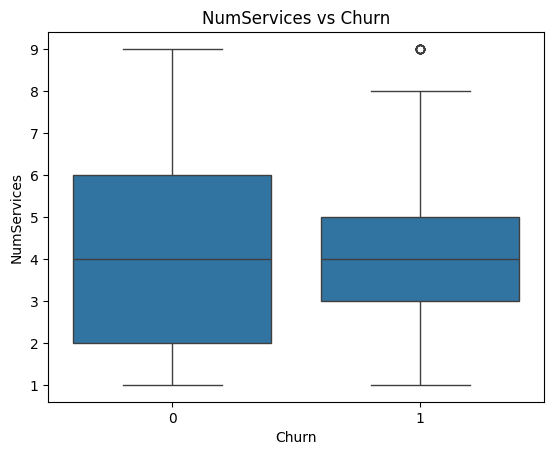

In [49]:
# Numericals vs churn
for col in num_cols:
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

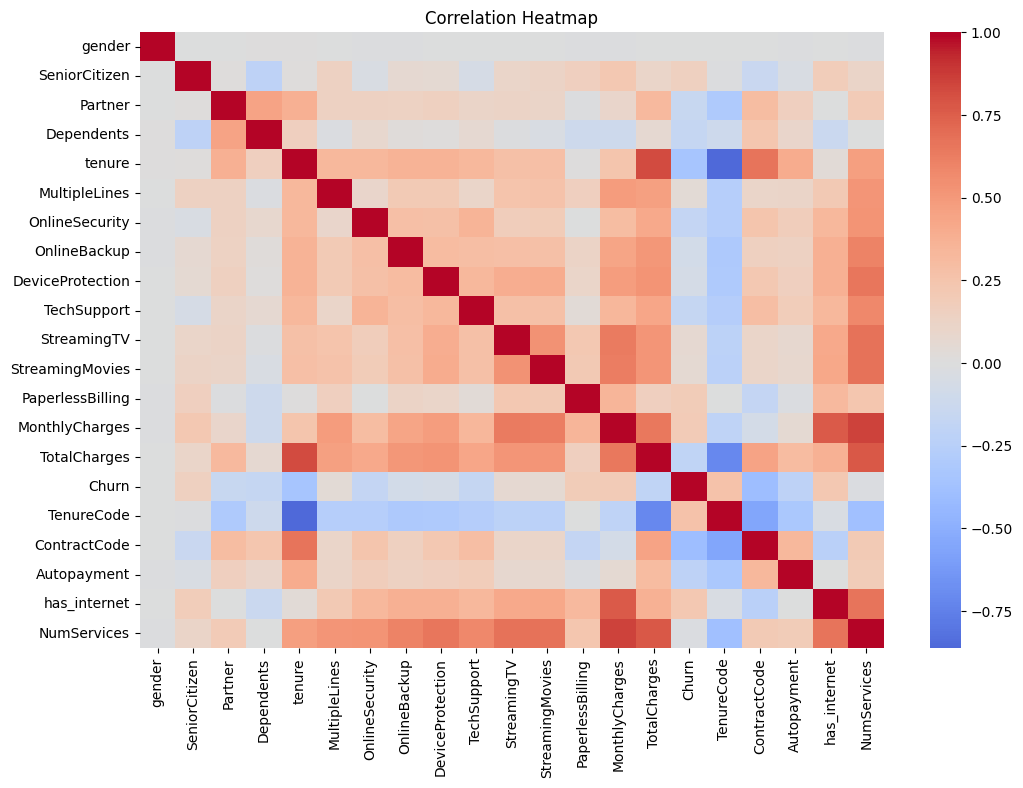

In [50]:
# Correlation Heatmap
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


From the above heatmap, we can see a correlation of the following variables with churn
- SeniorCitizen
- PaperlessBilling
- MonthlyCharges
- TenureCategory_new
- has_internet

In [51]:
df['NumServices']= df['NumServices'].astype('int')

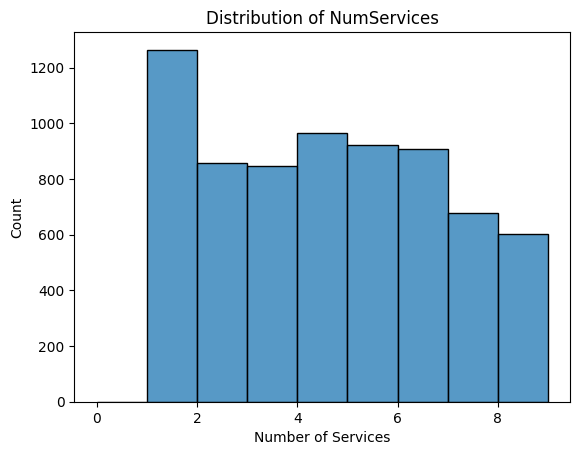

In [52]:
# Distribution of NumServices
sns.histplot(df['NumServices'], bins=range(0, df['NumServices'].max()+1), kde=False)
plt.title("Distribution of NumServices")
plt.xlabel("Number of Services")
plt.ylabel("Count")
plt.show()

**Majority of the customers in the dataset have only 1 service**

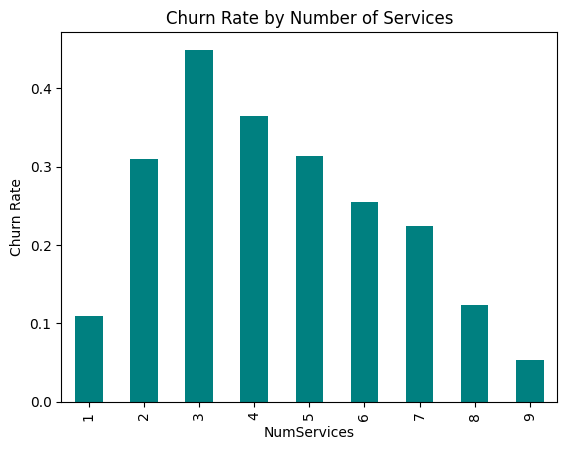

In [53]:
# Churn rate by NumServices
churn_by_services = df.groupby('NumServices')['Churn'].mean()
churn_by_services.plot(kind='bar', color='teal')
plt.title("Churn Rate by Number of Services")
plt.ylabel("Churn Rate")
plt.show()

**Customers having 3 services are more likely to churn**

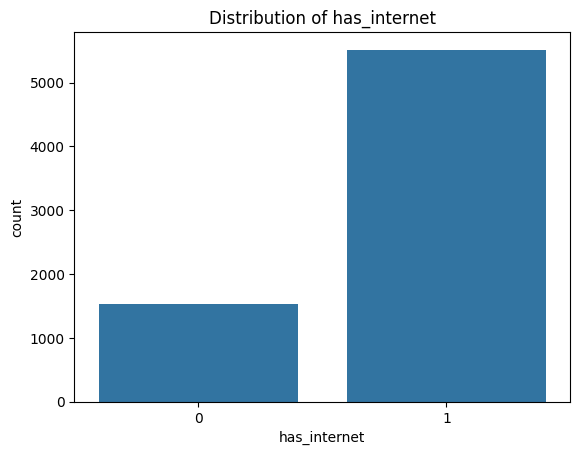

In [54]:
# Distribution of has_internet
sns.countplot(x='has_internet', data=df)
plt.title("Distribution of has_internet")
plt.show()

**Majority of the customers in the dataset have internet connection**

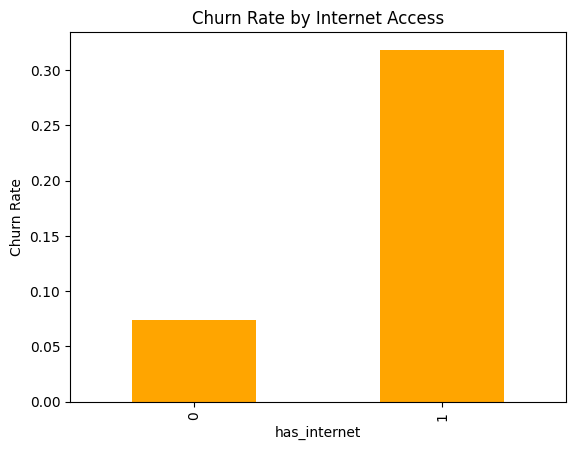

In [55]:
# Churn rate by internet access
churn_by_internet = df.groupby('has_internet')['Churn'].mean()
churn_by_internet.plot(kind='bar', color='orange')
plt.title("Churn Rate by Internet Access")
plt.ylabel("Churn Rate")
plt.show()

**This means that customers who have internet connection are more likely to churn**

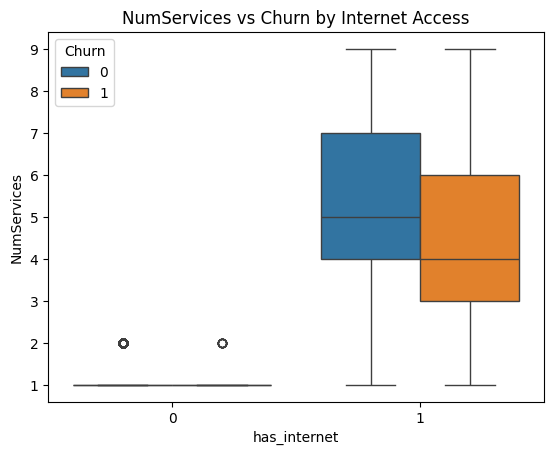

In [56]:
sns.boxplot(x='has_internet', y='NumServices', hue='Churn', data=df)
plt.title("NumServices vs Churn by Internet Access")
plt.show()

**From the boxplot, it can be interpreted that customers who are likely to churn have about 3-6 services, with the median value of 4 services. Whereas customers with an median value of 5 services were more likely to retain.** 

### Engineered Features
- **`NumServices`**:  
  - Distribution shows most customers subscribe to 2–4 services.  
  - Churn rate decreases as the number of services increases, confirming a *“bundle stickiness”* effect.  
  - Customers with 3 bundled services are more likely to churn.

- **`has_internet`**:  
  - Clear separation between customers with and without internet service.  
  - Churn rate is significantly higher among customers with internet service, highlighting internet as a key churn driver.  
  - Customers without internet service form a distinct segment with different churn behavior.

### Key Takeaways
- Short‑tenure, high‑charge customers are at greater risk of churn.  
- Month‑to‑month contracts and lack of autopay are strong churn predictors.  
- Engineered features (`NumServices`, `has_internet`) reveal patterns not visible in raw columns, improving interpretability and business insight.  
- These findings will guide feature selection and model design, while also providing actionable recommendations for customer retention strategies.

## Model Training

In [57]:
from lightgbm import LGBMClassifier

In [58]:
lgbm = LGBMClassifier(random_state=42)

### Feature selection for model training

In [59]:
# Split the data
from sklearn.model_selection import train_test_split

x = df.drop(columns=['Churn','PhoneService','InternetService','Contract','PaymentMethod','TenureCategory'])
y = df['Churn']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [60]:
# train the model
lgbm.fit(x_train, y_train)

# make predictions
lgbm_pred = lgbm.predict(x_test)
lgbm_proba = lgbm.predict_proba(x_test)[:,1]

[LightGBM] [Info] Number of positive: 1496, number of negative: 4138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000364 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 628
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265531 -> initscore=-1.017418
[LightGBM] [Info] Start training from score -1.017418


In [61]:
#evaluate the model performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, lgbm_pred))
print("Precision:", precision_score(y_test, lgbm_pred))
print("Recall:", recall_score(y_test, lgbm_pred))
print("F1 Score:", f1_score(y_test, lgbm_pred))
print("ROC AUC:", roc_auc_score(y_test, lgbm_proba))


Accuracy: 0.7970191625266146
Precision: 0.6426229508196721
Recall: 0.5254691689008043
F1 Score: 0.5781710914454278
ROC AUC: 0.8484361899241256


**LightGBM is performing with 79.7% accuracy**

## Feature Importance

             Feature  Importance
13    MonthlyCharges         889
14      TotalCharges         670
4             tenure         432
16      ContractCode         122
12  PaperlessBilling          99
0             gender          93
17       Autopayment          79
19       NumServices          74
2            Partner          69
6     OnlineSecurity          62


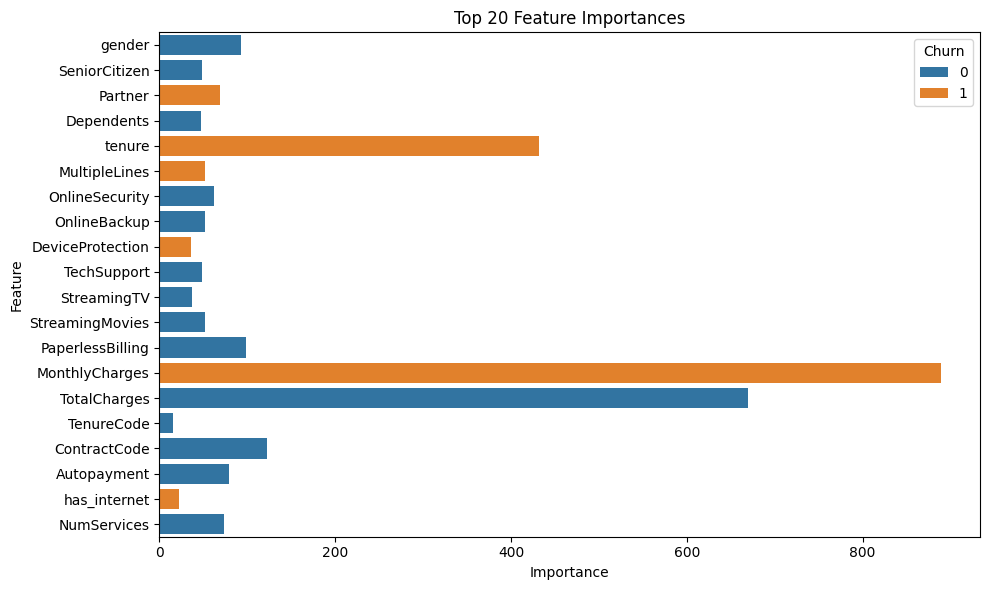

In [62]:
import matplotlib.pyplot as plt

# Get feature importances
feature_importances = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': lgbm.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display top features
print(feature_importances.head(10))

# Optional: Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature', hue=y)
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

## Tuning Classification threshold for LGBM

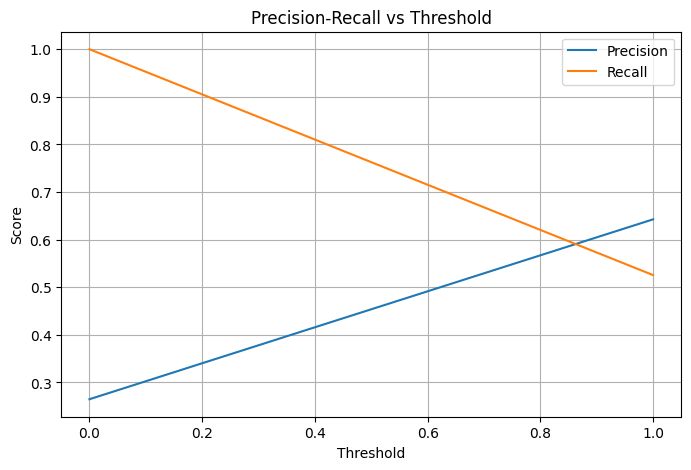

In [63]:
# Compute precision-recall pairs
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, lgbm_pred)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid()
plt.show()

### Key Observations update***
- At zero threshold, the precision is low (0.25-0.3), meaninig that there are alot of false positives. Whereas recall is very high (1.0) indicating that almost all positives are being classified as positive.
- As the threshold increases, precision increases, meaning fewer false positives. Whereas, recall decreases indicating more false negatives
- At threshold 0.5, there is a balance between precision and recall at score 0.9

From the business point of view for predicting customer churn, the impact of predicting false negatives (predicting customer will not churn, but they do) is more than predicting false positives (predicting customer will churn, but they dont). Therefore a threshold with higher recall is preferable for churn prediction. The recommended threshold value should be in between 0.38 and 0.5

### Confusion Matrix for custom threshold values

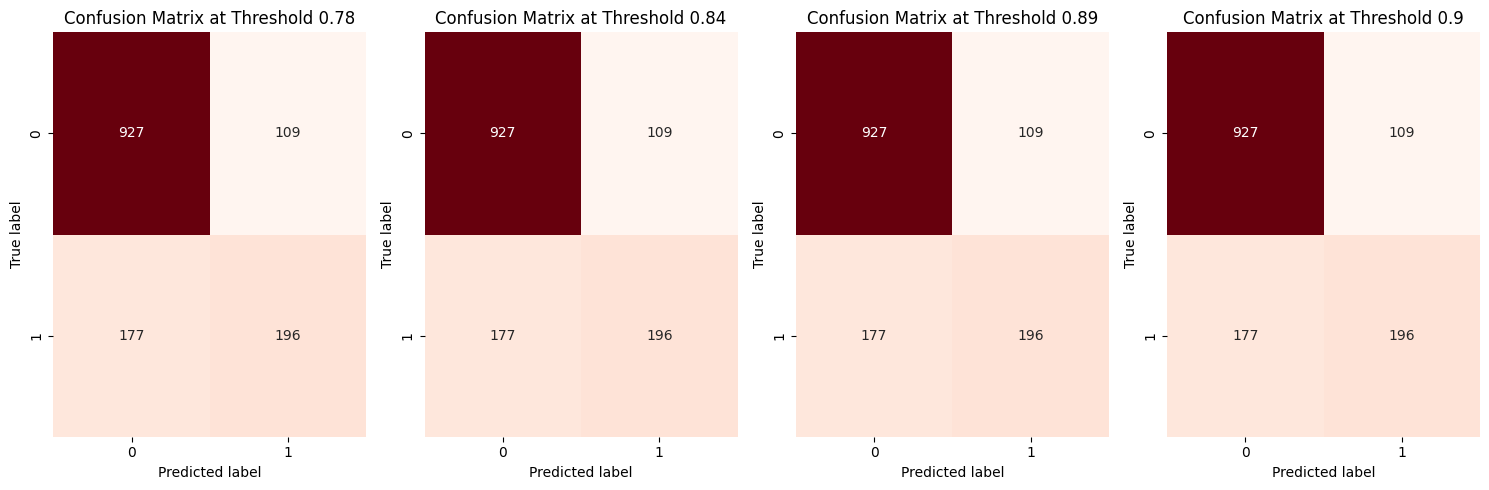

In [64]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

thresh_vals = [0.78, 0.84, 0.89, 0.90]

fig,axes = plt.subplots(1,4, figsize=(15,5))

for i,thresh in enumerate(thresh_vals):
    y_pred_thresh = (lgbm_pred >= thresh).astype(int)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_thresh)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axes[i])
    axes[i].set_title(f'Confusion Matrix at Threshold {thresh}')
    axes[i].set_xlabel('Predicted label')
    axes[i].set_ylabel('True label')

plt.tight_layout()
plt.show()

From the above figure, the threshold value of 0.38 produces the highest number of True positives and least number of False negatives, which is idealistic for churn prediction.

## Evaluating performance for chosen threshold

In [65]:
y_pred_tresh = (lgbm_pred >= 0.82).astype(int)
from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_test, y_pred_thresh))
print("ROC AUC:", roc_auc_score(y_test, lgbm_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1036
           1       0.64      0.53      0.58       373

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC AUC: 0.7101284068442245


## ROC Curve with Treshold Annotation

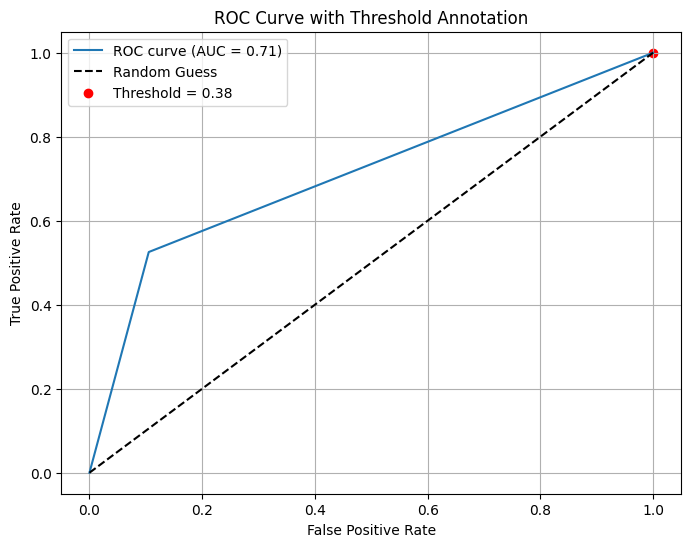

In [66]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, lgbm_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.scatter(fpr[np.argmin(abs(thresholds - 0.38))],
            tpr[np.argmin(abs(thresholds - 0.38))],
            color='red', label='Threshold = 0.38')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Threshold Annotation')
plt.legend()
plt.grid(True)
plt.show()

## SHAP summary

D:\Newfolder\envs\RP_Env\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


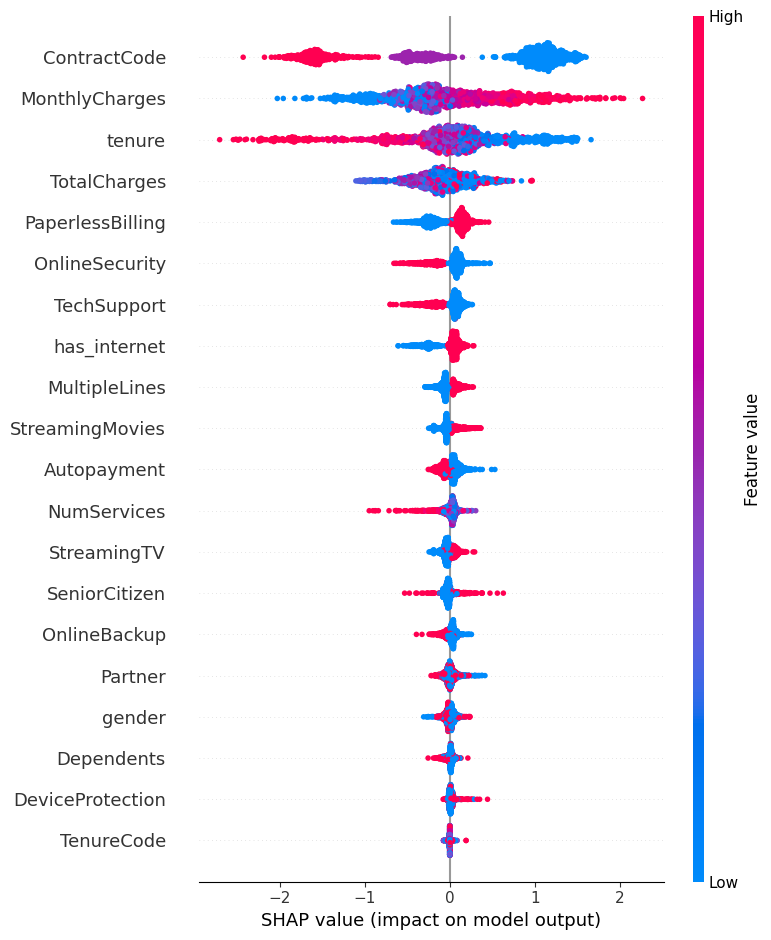

In [68]:
#Extract the model from pipeline

import shap
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(x_test)
shap.summary_plot(shap_values, x_test)

## Interpretation of SHAP chart
- CCntractCode, tenure, and MonthlyCharges are the top features that indicate positive churn prediction.
- For the feature tenure and ContractCode, the blue dots on the right side of y-axis suggests that, new customers (low tenure) with relatively short term contracts are more likely to churn.
- High monthly charges, represented by red dots, are on the positive side of SHAP value axis. This suggests that customers with high monlthy expenses are more likely to churn.
- SeniorCitizens are also more likely to churn. 
